In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

### 240909

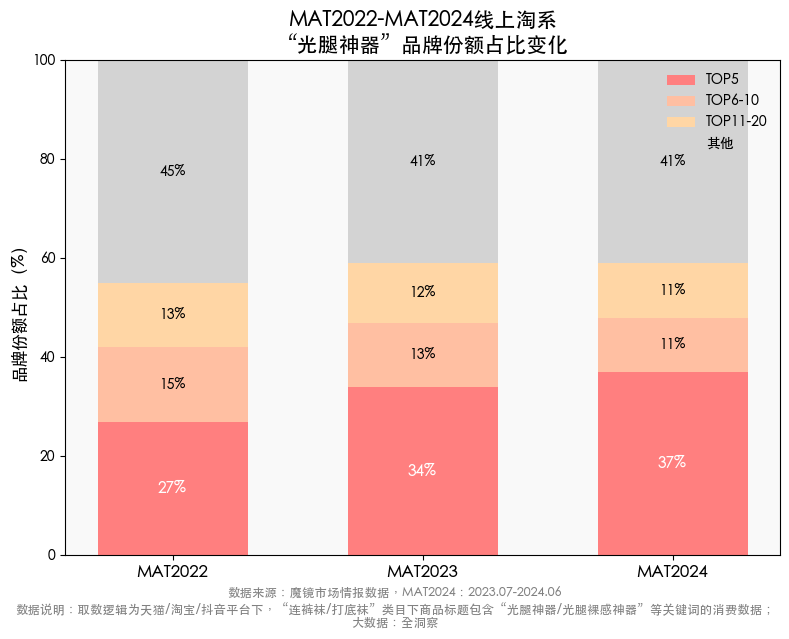

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 年份与份额数据
years = ['MAT2022', 'MAT2023', 'MAT2024']
top5 = np.array([27, 34, 37])
top6_10 = np.array([15, 13, 11])
top11_20 = np.array([13, 12, 11])
others = 100 - (top5 + top6_10 + top11_20)

# 堆叠柱状图位置
x = np.arange(len(years))
bar_width = 0.6

# 创建图形
fig, ax = plt.subplots(figsize=(8, 6))
fig.subplots_adjust(top=0.88)

# 画堆叠柱状图
p1 = ax.bar(x, top5, bar_width, label='TOP5', color='#FF7F7F')
p2 = ax.bar(x, top6_10, bar_width, bottom=top5, label='TOP6-10', color='#FFBFA2')
p3 = ax.bar(x, top11_20, bar_width, bottom=top5+top6_10, label='TOP11-20', color='#FFD6A5')
p4 = ax.bar(x, others, bar_width, bottom=top5+top6_10+top11_20, label='其他', color='#D3D3D3')

# 添加所有部分的数值标签
for i in range(len(years)):
    # TOP5
    ax.text(x[i], top5[i] / 2, f"{top5[i]}%", ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')

    # TOP6-10
    ax.text(x[i], top5[i] + top6_10[i] / 2, f"{top6_10[i]}%", ha='center', va='center',
            fontsize=10, color='black')

    # TOP11-20
    ax.text(x[i], top5[i] + top6_10[i] + top11_20[i] / 2, f"{top11_20[i]}%", ha='center', va='center',
            fontsize=10, color='black')

    # 其他
    ax.text(x[i], 100 - others[i] / 2, f"{others[i]}%", ha='center', va='center',
            fontsize=10, color='black')

# 设置坐标轴和标题
ax.set_title('MAT2022-MAT2024线上淘系\n“光腿神器”品牌份额占比变化', fontsize=15, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=12)
ax.set_ylabel('品牌份额占比（%）', fontsize=12)
ax.set_ylim(0, 100)

# 添加数据来源注释
source_text = ("数据来源：魔镜市场情报数据，MAT2024：2023.07-2024.06\n"
               "数据说明：取数逻辑为天猫/淘宝/抖音平台下，“连裤袜/打底袜”类目下商品标题包含“光腿神器/光腿裸感神器”等关键词的消费数据；\n"
               "大数据：全洞察")
plt.figtext(0.5, -0.05, source_text, wrap=True, horizontalalignment='center', fontsize=9, color='gray')

# 图例与样式
ax.legend(loc='upper right', frameon=False)
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()


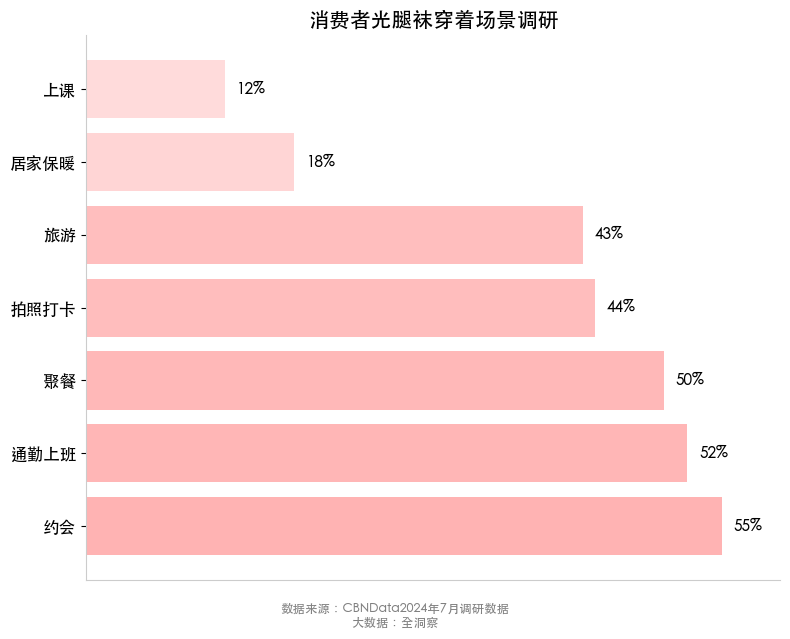

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 场景与对应比例
scenarios = ['约会', '通勤上班', '聚餐', '拍照打卡', '旅游', '居家保暖', '上课']
percentages = [55, 52, 50, 44, 43, 18, 12]

# 倒序排列（为了从上到下显示）
scenarios = scenarios[::-1]
percentages = percentages[::-1]
y_pos = np.arange(len(scenarios))

# 创建渐变色映射
cmap = LinearSegmentedColormap.from_list("softpink", ["#ffe6e6", "#ffb3b3"])

# 绘图
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(y_pos, percentages, color=cmap(percentages / np.max(percentages)))

# 添加文字标签
for i, (p, label) in enumerate(zip(percentages, scenarios)):
    ax.text(p + 1, i, f"{p}%", va='center', fontsize=11)

# 设置标题和标签
ax.set_yticks(y_pos)
ax.set_yticklabels(scenarios, fontsize=12)
ax.invert_yaxis()  # 最受欢迎的场景显示在最上面
ax.set_xlim(0, 60)
ax.set_title("消费者光腿袜穿着场景调研", fontsize=15, weight='bold')

# 去除边框和多余刻度
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.xaxis.set_visible(False)

# 添加数据来源
source_text = "数据来源：CBNData2024年7月调研数据\n大数据：全洞察"
plt.figtext(0.5, -0.05, source_text, wrap=True, horizontalalignment='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()


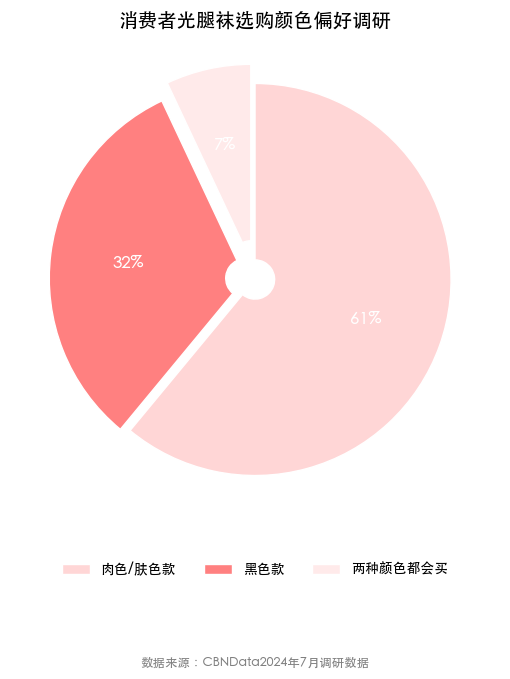

In [4]:
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 数据
labels = ['肉色/肤色款', '黑色款', '两种颜色都会买']
sizes = [61, 32, 7]
colors = ['#ffd6d6', '#ff8080', '#ffeaea']  # 贴近原图的渐变粉调配色
explode = (0, 0.05, 0.1)  # 突出显示后两项

# 创建图形
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=sizes,
    explode=explode,
    colors=colors,
    startangle=90,
    counterclock=False,
    autopct='%1.0f%%',
    textprops={'fontsize': 12, 'color': 'white'},
    wedgeprops=dict(width=0.9, edgecolor='white')
)

# 设置标题
ax.set_title("消费者光腿袜选购颜色偏好调研", fontsize=14, weight='bold')

# 添加图例
ax.legend(wedges, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=False, fontsize=10)

# 添加数据来源
source_text = "数据来源：CBNData2024年7月调研数据"
plt.figtext(0.5, -0.12, source_text, wrap=True, horizontalalignment='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()


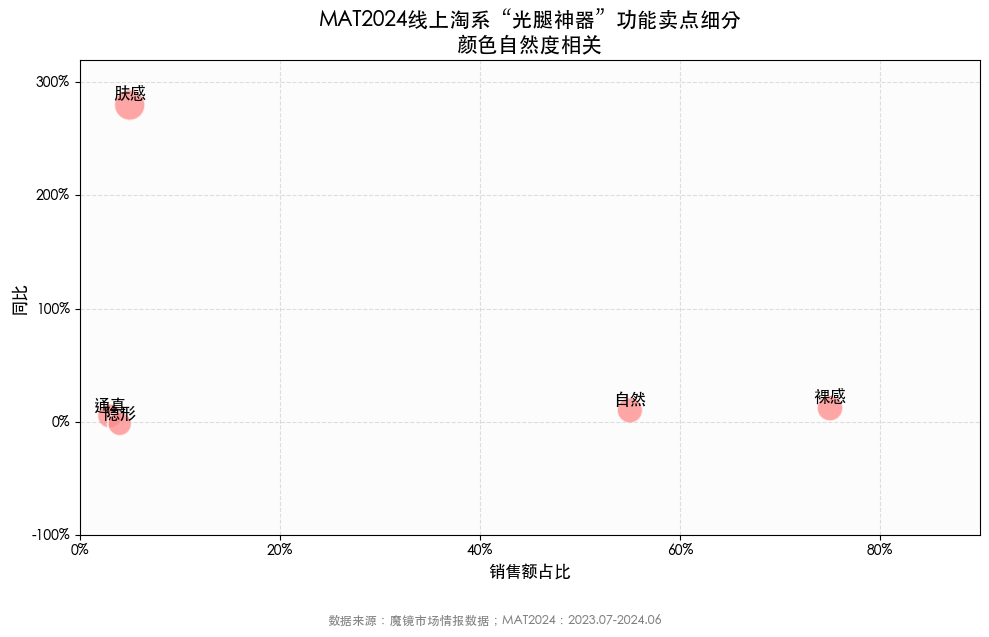

In [5]:
import matplotlib.pyplot as plt

# 数据定义（更贴近原图精确位置）
labels = ['肤感', '通真', '隐形', '自然', '裸感']
x_sales_ratio = [0.05, 0.03, 0.04, 0.55, 0.75]  # 销售额占比
y_growth_rate = [2.8, 0.05, -0.02, 0.1, 0.12]   # 同比增速
sizes = [500, 320, 300, 350, 360]  # 气泡大小人为设置以接近原图视觉权重

# 创建图表
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制气泡图
ax.scatter(
    x_sales_ratio,
    y_growth_rate,
    s=sizes,
    c='#FF8888',
    alpha=0.75,
    edgecolors='white',
    linewidth=1.5
)

# 添加文本标签
for i in range(len(labels)):
    ax.text(x_sales_ratio[i], y_growth_rate[i] + 0.03, labels[i],
            ha='center', va='bottom', fontsize=12)

# 坐标轴设置
ax.set_title('MAT2024线上淘系“光腿神器”功能卖点细分\n颜色自然度相关', fontsize=15, weight='bold')
ax.set_xlabel('销售额占比', fontsize=12)
ax.set_ylabel('同比', fontsize=12)

# 设置刻度格式与范围
ax.set_xlim(0, 0.9)
ax.set_ylim(-0.3, 3.2)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8])
ax.set_xticklabels(['0%', '20%', '40%', '60%', '80%'])
ax.set_yticks([-1, 0, 1, 2, 3])
ax.set_yticklabels(['-100%', '0%', '100%', '200%', '300%'])

# 添加网格与背景
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_facecolor('#fcfcfc')

# 数据来源说明
source_text = "数据来源：魔镜市场情报数据；MAT2024：2023.07-2024.06"
plt.figtext(0.5, -0.05, source_text, wrap=True, horizontalalignment='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()
